In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.datasets import make_blobs
%matplotlib inline


In [13]:
X,y = make_blobs(n_samples=1000,centers=3,n_features=2)

In [14]:
X

array([[ 5.55328132,  3.88382546],
       [ 9.17125967,  1.96322623],
       [ 2.96018176, -1.38525893],
       ...,
       [ 9.10564332,  0.68216861],
       [ 2.02005738, -0.98775952],
       [ 4.32410463,  4.49786676]], shape=(1000, 2))

In [15]:
y

array([2, 0, 1, 2, 1, 0, 1, 2, 0, 0, 1, 0, 1, 2, 0, 1, 1, 2, 2, 2, 2, 0,
       2, 0, 1, 0, 0, 0, 1, 0, 0, 2, 0, 0, 2, 1, 1, 1, 0, 0, 2, 0, 2, 1,
       1, 0, 2, 1, 1, 1, 2, 1, 1, 0, 0, 1, 1, 2, 2, 0, 2, 2, 2, 1, 2, 2,
       2, 0, 1, 0, 2, 1, 2, 0, 2, 2, 2, 2, 0, 1, 1, 1, 0, 0, 0, 0, 0, 2,
       0, 1, 0, 0, 1, 1, 2, 0, 2, 2, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 2, 0,
       0, 2, 2, 2, 0, 1, 0, 1, 0, 2, 1, 2, 2, 0, 2, 2, 1, 2, 0, 0, 2, 0,
       2, 2, 0, 0, 1, 2, 2, 0, 2, 2, 0, 2, 2, 0, 0, 1, 1, 1, 0, 2, 2, 1,
       1, 0, 2, 2, 2, 1, 2, 1, 0, 0, 2, 0, 2, 0, 0, 0, 1, 2, 2, 0, 0, 2,
       1, 0, 2, 2, 2, 0, 2, 2, 0, 0, 1, 0, 2, 0, 1, 2, 2, 0, 0, 1, 0, 2,
       1, 0, 2, 1, 0, 2, 1, 2, 0, 1, 0, 1, 2, 0, 0, 0, 1, 0, 0, 2, 0, 1,
       1, 2, 2, 1, 0, 2, 1, 1, 1, 2, 1, 2, 1, 2, 1, 1, 1, 1, 1, 1, 1, 0,
       0, 2, 0, 1, 1, 2, 2, 0, 0, 0, 1, 0, 2, 1, 2, 2, 0, 1, 0, 1, 0, 1,
       1, 2, 2, 2, 0, 2, 0, 1, 0, 2, 1, 0, 0, 1, 0, 1, 0, 2, 1, 1, 2, 2,
       1, 1, 2, 0, 1, 0, 1, 2, 1, 0, 2, 0, 2, 1, 2,

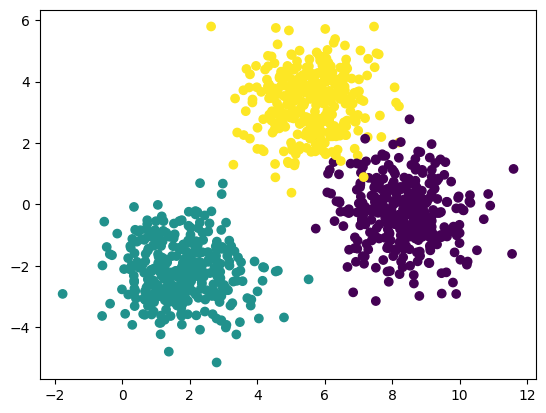

In [17]:
plt.scatter(X[:,0],X[:,1],c=y)

In [8]:
## standardization-- feature scaling technique
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [9]:
from sklearn.model_selection import train_test_split


In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [20]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [21]:
from sklearn.cluster import KMeans

In [22]:
## elbow method to select k value 
wcss = []
for k in range(1,11):
    Kmeans=KMeans(n_clusters=k , init='k-means++')
    Kmeans.fit(X_train_scaled)
    wcss.append(Kmeans.inertia_)

In [23]:
wcss

[1340.0000000000002,
 539.0334330787194,
 190.74246414036025,
 162.77012686060047,
 138.7084270903501,
 117.2947389641313,
 107.88361961408415,
 93.2966346977936,
 83.75198744953912,
 78.41892325874649]

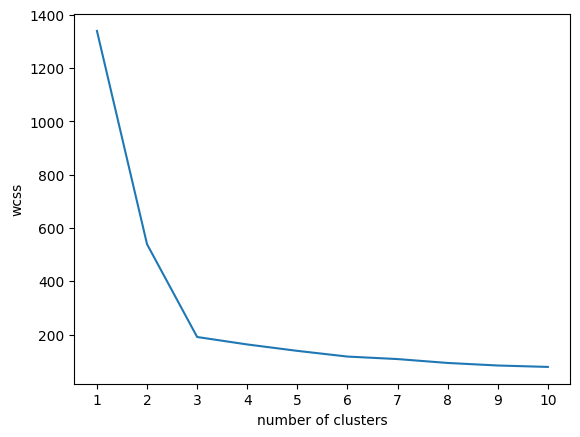

In [24]:
## plot elbow curve
plt.plot(range(1,11),wcss)
plt.xticks(range(1,11))
plt.xlabel("number of clusters")
plt.ylabel('wcss')
plt.show()

In [25]:
Kmeans=KMeans(n_clusters=3 , init='k-means++')

In [27]:
Kmeans.fit_predict(X_train_scaled)

array([0, 2, 0, 1, 0, 1, 0, 2, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 2, 2, 2, 1,
       2, 2, 2, 2, 0, 2, 1, 0, 1, 1, 2, 1, 0, 1, 2, 2, 1, 1, 2, 0, 0, 2,
       1, 2, 1, 2, 0, 2, 1, 2, 0, 1, 1, 2, 2, 0, 1, 2, 2, 2, 0, 0, 1, 1,
       2, 2, 0, 2, 1, 0, 1, 0, 0, 0, 1, 2, 1, 2, 1, 2, 0, 1, 1, 1, 0, 2,
       1, 1, 0, 2, 0, 2, 1, 2, 2, 0, 1, 2, 0, 1, 0, 0, 2, 1, 0, 1, 2, 0,
       1, 1, 1, 0, 2, 2, 2, 1, 1, 1, 0, 2, 0, 2, 0, 1, 2, 2, 0, 1, 0, 0,
       0, 0, 2, 1, 2, 0, 0, 1, 0, 1, 2, 1, 2, 0, 1, 1, 0, 2, 0, 0, 2, 2,
       1, 1, 0, 1, 2, 0, 0, 0, 2, 2, 2, 0, 2, 2, 2, 1, 2, 2, 0, 0, 2, 2,
       0, 1, 1, 0, 0, 1, 2, 1, 0, 1, 0, 0, 2, 0, 1, 2, 1, 1, 0, 2, 1, 0,
       0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 2, 2, 0, 1, 1, 0, 1, 0, 2, 0, 0, 1,
       2, 2, 2, 0, 2, 1, 2, 2, 0, 2, 1, 0, 0, 2, 1, 0, 0, 1, 2, 2, 1, 0,
       0, 0, 2, 1, 2, 1, 0, 1, 2, 0, 2, 2, 0, 1, 0, 1, 2, 0, 1, 1, 1, 1,
       2, 1, 1, 0, 1, 1, 0, 0, 2, 1, 2, 0, 1, 1, 1, 2, 0, 1, 2, 0, 0, 2,
       0, 1, 1, 2, 1, 0, 0, 0, 1, 0, 1, 2, 0, 1, 1,

In [28]:
y_pred=Kmeans.predict(X_test_scaled)

In [29]:
y_pred

array([1, 1, 1, 1, 2, 0, 1, 2, 1, 1, 0, 0, 1, 0, 0, 1, 2, 2, 0, 1, 2, 2,
       1, 1, 0, 1, 2, 1, 2, 2, 0, 2, 2, 0, 1, 1, 1, 0, 2, 2, 1, 0, 0, 0,
       1, 1, 2, 0, 2, 0, 2, 1, 1, 1, 2, 2, 0, 1, 0, 2, 0, 2, 1, 1, 2, 2,
       0, 2, 0, 1, 1, 1, 0, 2, 1, 2, 1, 2, 0, 2, 0, 2, 2, 2, 0, 0, 1, 0,
       2, 1, 1, 0, 0, 2, 1, 2, 0, 2, 1, 2, 1, 0, 1, 0, 0, 2, 0, 2, 2, 1,
       1, 2, 0, 2, 2, 1, 0, 1, 1, 1, 2, 1, 1, 2, 1, 2, 0, 0, 0, 0, 2, 0,
       0, 1, 2, 1, 1, 2, 2, 0, 1, 0, 2, 0, 0, 2, 2, 2, 0, 1, 1, 0, 1, 2,
       2, 0, 2, 1, 0, 0, 1, 2, 1, 2, 0, 1, 0, 0, 1, 2, 1, 0, 2, 2, 0, 2,
       0, 1, 1, 1, 1, 1, 2, 1, 0, 0, 0, 1, 1, 1, 0, 2, 1, 2, 2, 2, 1, 2,
       0, 2, 2, 1, 2, 0, 0, 0, 2, 0, 2, 0, 0, 0, 2, 0, 1, 2, 1, 2, 1, 1,
       0, 0, 0, 1, 2, 1, 1, 2, 0, 0, 1, 2, 2, 2, 2, 0, 0, 1, 0, 1, 0, 1,
       1, 2, 0, 2, 0, 0, 2, 1, 2, 1, 1, 1, 1, 1, 1, 2, 0, 2, 1, 0, 0, 0,
       0, 1, 1, 0, 2, 1, 2, 2, 2, 2, 2, 2, 2, 0, 1, 0, 0, 1, 1, 1, 2, 1,
       1, 0, 1, 1, 1, 0, 1, 0, 2, 1, 0, 2, 0, 2, 0,

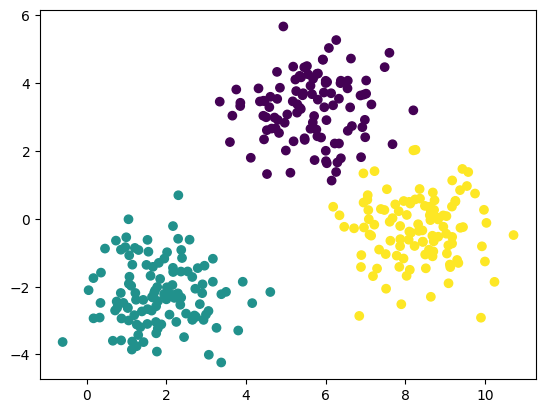

In [30]:
plt.scatter(X_test[:,0],X_test[:,1],c=y_pred)

In [31]:
## validating the k value 
## kneelocator
##silhoutee scoring 


In [32]:
## kneelocator
!pip install kneed

In [34]:
# correct import and use KneeLocator to detect the elbow
from kneed import KneeLocator as kneedLocator

In [35]:

kl = kneedLocator(range(1, 11), wcss, curve="convex", direction="decreasing")
print("elbow:", kl.knee)

elbow: 3


In [36]:
##silhoutte scoring 
from sklearn.metrics import silhouette_score

In [37]:
silhouette_coefficient = []
for k in range (2,11):
    Kmeans=KMeans(n_clusters=k , init='k-means++')
    Kmeans.fit(X_train_scaled)
    score = silhouette_score(X_train_scaled,Kmeans.labels_)
    silhouette_coefficient.append(score)

In [41]:
silhouette_coefficient

[0.577940545094859,
 0.6463126933584499,
 0.5301302399480252,
 0.40114092306231824,
 0.33559430841204463,
 0.34159882573814937,
 0.3159342154255289,
 0.32374231689093363,
 0.3403506974888691]

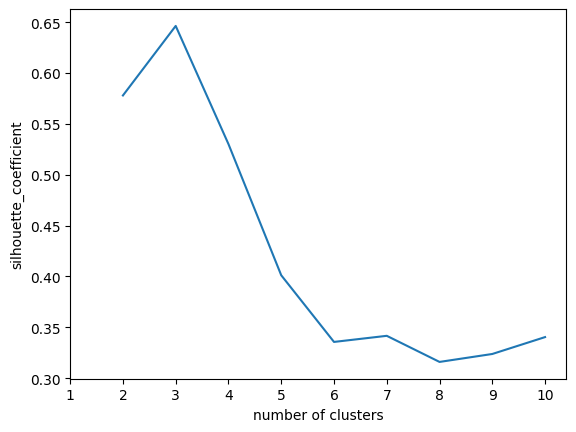

In [42]:
plt.plot(range(2,11),silhouette_coefficient)
plt.xticks(range(1,11))
plt.xlabel("number of clusters")
plt.ylabel('silhouette_coefficient')
plt.show()